# Solución de la Ecuación de Difusión por el Método de Líneas (MELIN)

**Problema:** Distribución de temperatura en una pared infinita de ancho $l = 1$ m

**Ecuación de difusión:**
$$\frac{\partial T}{\partial t} = \alpha^2 \frac{\partial^2 T}{\partial x^2}, \quad x \in (0, l),\; t > 0$$

**Condiciones de frontera:**
$$T(0,t) = 0 \qquad \frac{\partial T}{\partial x}\bigg|_{x=l} = 0$$

**Condición inicial:**
$$T(x, 0) = 100$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.integrate import solve_ivp
import pandas as pd

# ── Parámetros del problema ──────────────
alpha = 0.2       # Constante de difusión térmica
L     = 1.0       # Ancho de la pared [m]
N     = 10        # Número de divisiones espaciales
dx    = L / N     # Paso espacial
T0    = 100.0     # Temperatura inicial [°C]

x = np.linspace(0, L, N+1)

print(f"α  = {alpha}")
print(f"l  = {L} m")
print(f"N  = {N}")
print(f"Δx = {dx}")
print(f"Criterio estabilidad → α²Δt/Δx² = {alpha**2 * 0.05 / dx**2:.3f} ≤ 0.5 ✔")

α  = 0.2
l  = 1.0 m
N  = 10
Δx = 0.1
Criterio estabilidad → α²Δt/Δx² = 0.200 ≤ 0.5 ✔


## Sistema de EDOs — Método de Líneas

Se discretiza la derivada espacial con diferencias finitas centradas:

$$\frac{dT_i}{dt} = \alpha^2 \frac{T_{i+1} - 2T_i + T_{i-1}}{(\Delta x)^2}, \quad i = 2, 3, \ldots, N$$

Para la frontera aislada $x = l$ se usa diferencia hacia atrás de orden $\mathcal{O}((\Delta x)^2)$:

$$\left.\frac{\partial T}{\partial x}\right|_{x=l} = 0 \implies T_{N+1} = \frac{4T_N - T_{N-1}}{3}$$

In [3]:
def derivs(t, T):
    dTdt = np.zeros_like(T)
    a2   = alpha**2
    dx2  = dx**2

    # Frontera fija x=0
    dTdt[0] = 0.0

    # Puntos interiores
    for i in range(1, N):
        dTdt[i] = a2 * (T[i+1] - 2*T[i] + T[i-1]) / dx2

    # Frontera aislada x=l  →  Neumann
    T_der   = (4*T[N] - T[N-1]) / 3.0
    dTdt[N] = a2 * (T_der - 2*T[N] + T[N-1]) / dx2

    return dTdt

In [4]:
# ── Condición inicial ────────────────────
T_init    = np.full(N+1, T0)
T_init[0] = 0.0               # Frontera fría

# ── Intervalo de tiempo ──────────────────
t_start = 0.0
t_end   = 30.0
h       = 0.05
t_eval  = np.arange(t_start, t_end + h, h)

# ── Integración RK45 ─────────────────────
sol = solve_ivp(
    derivs,
    [t_start, t_end],
    T_init,
    method  = 'RK45',
    t_eval  = t_eval,
    rtol    = 1e-6,
    atol    = 1e-8
)

t_sol = sol.t
T_sol = sol.y

print(f"Integración exitosa : {sol.success}")
print(f"Puntos × Tiempos    : {T_sol.shape}")

Integración exitosa : True
Puntos × Tiempos    : (11, 601)


## Solución analítica

Por separación de variables (ecuación 3 del artículo):

$$T(x,t) = \frac{400}{\pi} \sum_{n=0}^{\infty} \frac{1}{2n+1} \sin\!\left(\frac{2n+1}{2l}\pi x\right) \exp\!\left(-\alpha^2\left(\frac{2n+1}{2l}\pi\right)^2 t\right)$$

In [5]:
def T_analitica(x, t, alpha=alpha, L=L, n_terms=50):
    T = np.zeros_like(x, dtype=float)
    for n in range(n_terms):
        k  = (2*n + 1) / (2*L) * np.pi
        T += (1/(2*n+1)) * np.sin(k*x) * np.exp(-alpha**2 * k**2 * t)
    return (400/np.pi) * T

## Gráfica 1 — Superficie 3D  $T(x, t)$

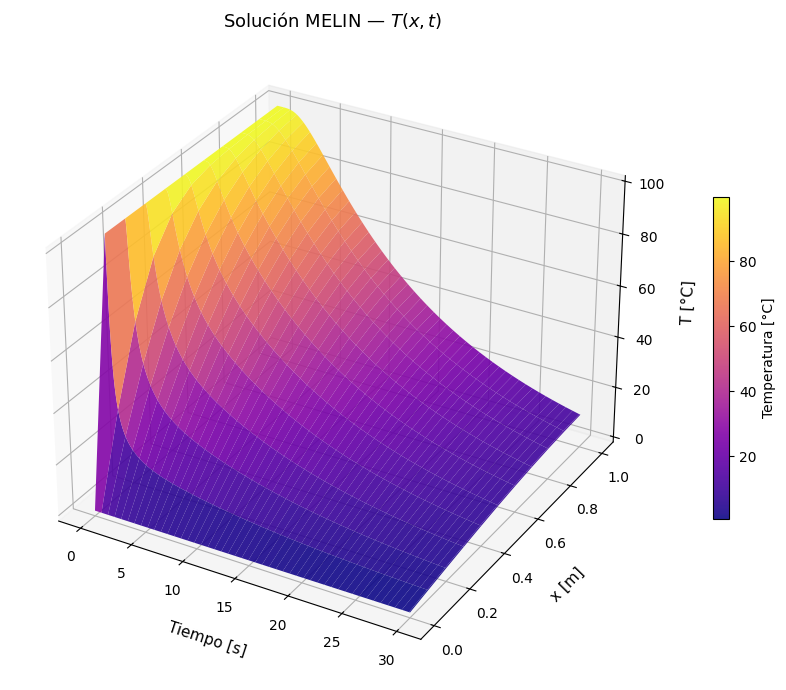

In [6]:
fig = plt.figure(figsize=(12, 7))
ax  = fig.add_subplot(111, projection='3d')

X_grid, T_grid = np.meshgrid(x, t_sol)
Z_grid = T_sol.T

surf = ax.plot_surface(T_grid, X_grid, Z_grid,
                       cmap='plasma', edgecolor='none', alpha=0.9)

ax.set_xlabel('Tiempo [s]', fontsize=11, labelpad=10)
ax.set_ylabel('x [m]',      fontsize=11, labelpad=10)
ax.set_zlabel('T [°C]',     fontsize=11, labelpad=10)
ax.set_title('Solución MELIN — $T(x,t)$', fontsize=13)
fig.colorbar(surf, ax=ax, shrink=0.5, label='Temperatura [°C]')
plt.tight_layout()
plt.show()

## Gráfica 2 — Perfiles $T(x)$ a distintos tiempos

Línea continua = MELIN  |  Línea punteada = Analítica

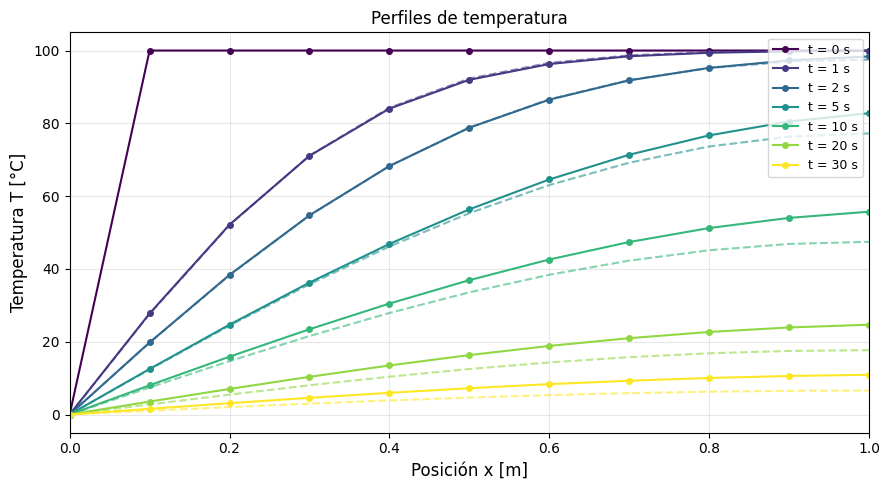

In [7]:
tiempos_plot = [0, 1, 2, 5, 10, 20, 30]
colores      = cm.viridis(np.linspace(0, 1, len(tiempos_plot)))

fig, ax = plt.subplots(figsize=(9, 5))

for tp, color in zip(tiempos_plot, colores):
    idx = np.argmin(np.abs(t_sol - tp))
    ax.plot(x, T_sol[:, idx], '-o', color=color, markersize=4, label=f't = {tp} s')
    if tp > 0:
        ax.plot(x, T_analitica(x, tp), '--', color=color, alpha=0.6)

ax.set_xlabel('Posición x [m]', fontsize=12)
ax.set_ylabel('Temperatura T [°C]', fontsize=12)
ax.set_title('Perfiles de temperatura', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, L);  ax.set_ylim(-5, 105)
plt.tight_layout()
plt.show()

## Gráfica 3 — Evolución temporal en puntos fijos $x_i$

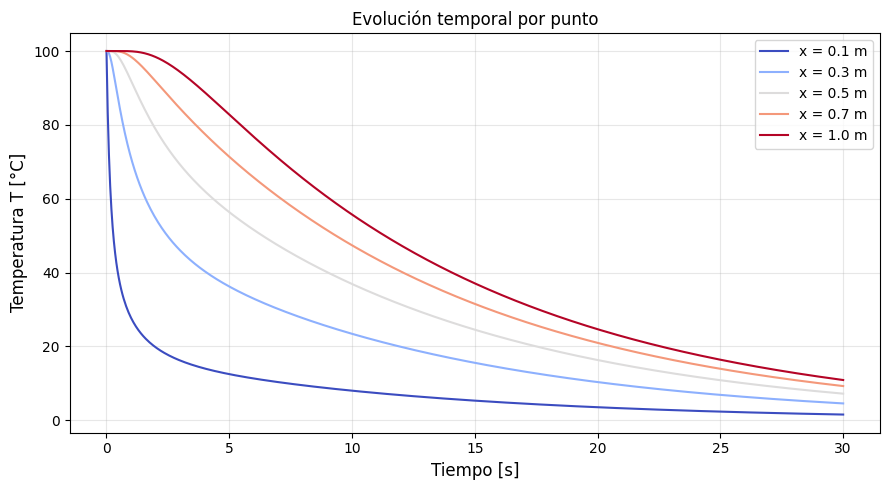

In [8]:
puntos  = [1, 3, 5, 7, 10]
colores = cm.coolwarm(np.linspace(0, 1, len(puntos)))

fig, ax = plt.subplots(figsize=(9, 5))

for idx_x, color in zip(puntos, colores):
    ax.plot(t_sol, T_sol[idx_x, :], color=color, label=f'x = {x[idx_x]:.1f} m')

ax.set_xlabel('Tiempo [s]', fontsize=12)
ax.set_ylabel('Temperatura T [°C]', fontsize=12)
ax.set_title('Evolución temporal por punto', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Gráfica 4 — Error absoluto: MELIN vs Analítica

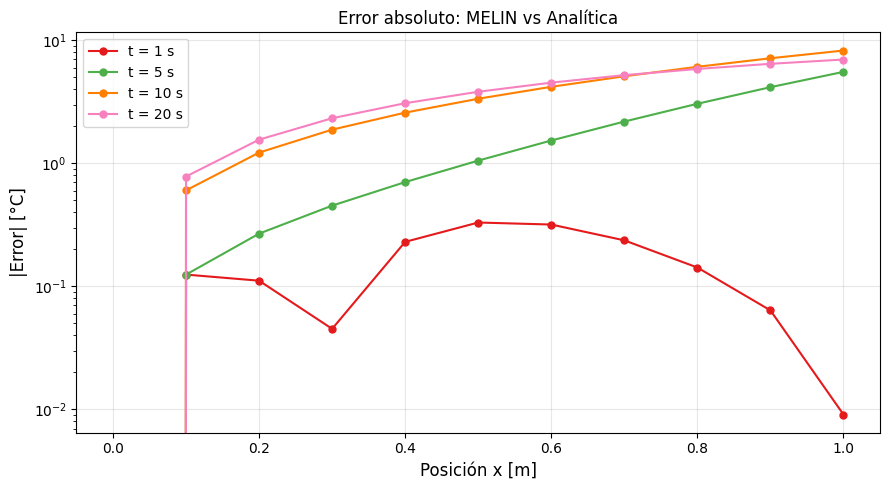

In [9]:
tiempos_error = [1, 5, 10, 20]
colores       = cm.Set1(np.linspace(0, 0.8, len(tiempos_error)))

fig, ax = plt.subplots(figsize=(9, 5))

for tp, color in zip(tiempos_error, colores):
    idx  = np.argmin(np.abs(t_sol - tp))
    err  = np.abs(T_sol[:, idx] - T_analitica(x, tp))
    ax.plot(x, err, '-o', color=color, markersize=5, label=f't = {tp} s')

ax.set_xlabel('Posición x [m]', fontsize=12)
ax.set_ylabel('|Error| [°C]', fontsize=12)
ax.set_title('Error absoluto: MELIN vs Analítica', fontsize=12)
ax.legend(fontsize=10)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Tabla comparativa — Numérico vs Analítico

Comparación en $t = 5$ s en todos los puntos de la malla

In [10]:
t_tabla = 5.0
idx     = np.argmin(np.abs(t_sol - t_tabla))
T_num   = T_sol[:, idx]
T_an    = T_analitica(x, t_tabla)

df = pd.DataFrame({
    'x [m]'       : np.round(x,              2),
    'T numérico'  : np.round(T_num,           4),
    'T analítico' : np.round(T_an,            4),
    '|Error|'     : np.round(np.abs(T_num - T_an), 6)
})

display(df)

,x [m],T numérico,T analítico,|Error|
0,0.0,0.0000,0.0000,0.000000
1,0.1,12.5116,12.3869,0.124736
2,0.2,24.6935,24.4248,0.268699
3,0.3,36.2367,35.7830,0.453678
4,0.4,46.8696,46.1647,0.704954
5,0.5,56.3713,55.3176,1.053703
6,0.6,64.5752,63.0401,1.535082
7,0.7,71.3692,69.1806,2.188639
8,0.8,76.6860,73.6327,3.053273
9,0.9,80.4932,76.3286,4.164557


# Fortran

In [11]:
# ── Leer archivo Fortran ─────────────────
datos = np.loadtxt('MELINF.dat')

t_f   = datos[:, 0]        # Tiempos
T_f   = datos[:, 1:N+1]    # Temperaturas T1..T10  (N puntos)
T_fd  = datos[:, N+1]      # Temperatura frontera aislada

print(f"Pasos leídos : {len(t_f)}")
print(f"t inicio     : {t_f[0]}")
print(f"t final      : {t_f[-1]}")
print(f"Shape datos  : {T_f.shape}")

Pasos leídos : 602
t inicio     : 0.0
t final      : 30.05
Shape datos  : (602, 10)


### Gráfica 1F — Superficie 3D  $T(x,t)$ — Fortran

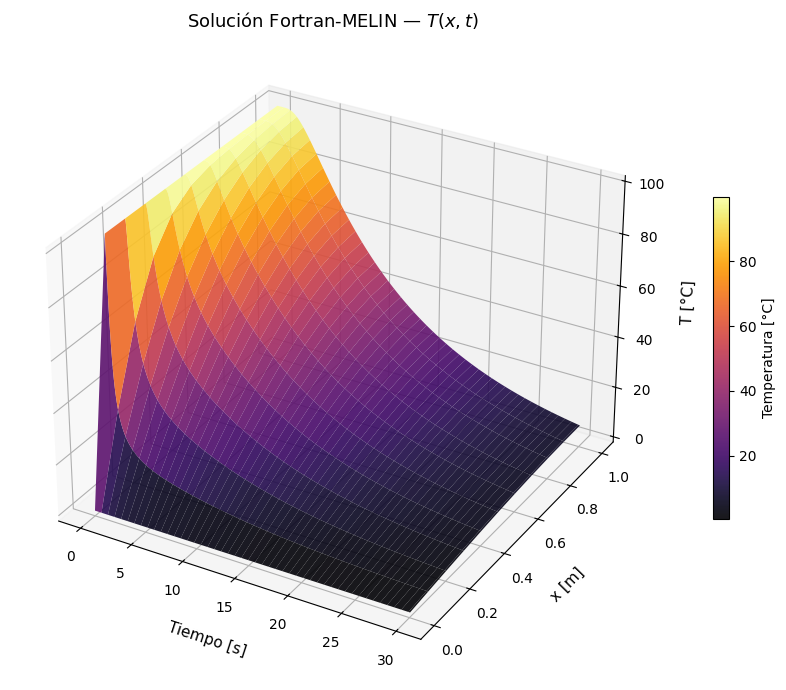

In [17]:
# x completo: 11 puntos de 0.0 a 1.0
x_f = np.linspace(0, L, N + 1)

# Z completo: concatenar T_f (10 cols) + T_fd (1 col) → shape (601, 11)
Z_grid_f = np.column_stack([T_f, T_fd])

X_grid_f, T_grid_f = np.meshgrid(x_f, t_f)   # ambos 601×11

fig = plt.figure(figsize=(12, 7))
ax  = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(T_grid_f, X_grid_f, Z_grid_f,
                       cmap='inferno', edgecolor='none', alpha=0.9)

ax.set_xlabel('Tiempo [s]', fontsize=11, labelpad=10)
ax.set_ylabel('x [m]',      fontsize=11, labelpad=10)
ax.set_zlabel('T [°C]',     fontsize=11, labelpad=10)
ax.set_title('Solución Fortran-MELIN — $T(x,t)$', fontsize=13)
fig.colorbar(surf, ax=ax, shrink=0.5, label='Temperatura [°C]')
plt.tight_layout()
plt.show()

### Gráfica 2F — Perfiles $T(x)$ a distintos tiempos — Fortran vs Analítica

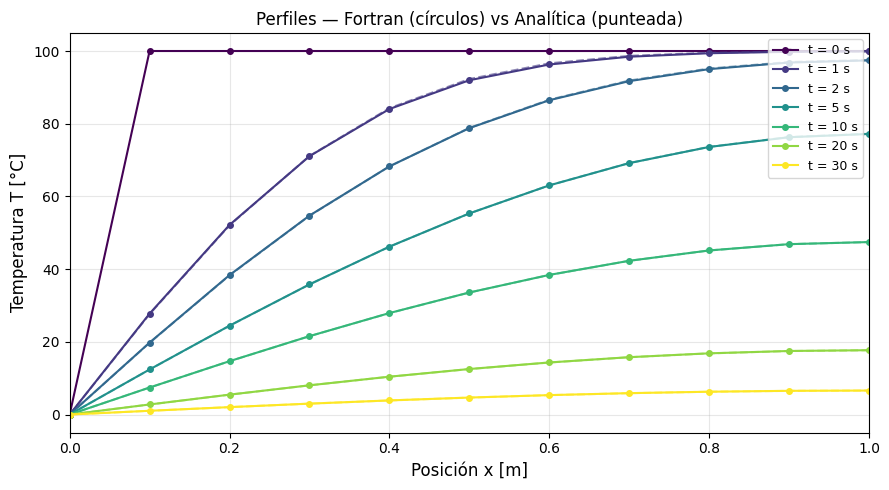

In [18]:
tiempos_plot = [0, 1, 2, 5, 10, 20, 30]
colores      = cm.viridis(np.linspace(0, 1, len(tiempos_plot)))

x_f = np.linspace(0, L, N + 1)   # 11 puntos: 0.0, 0.1, ..., 1.0

fig, ax = plt.subplots(figsize=(9, 5))

for tp, color in zip(tiempos_plot, colores):
    idx    = np.argmin(np.abs(t_f - tp))
    T_fila = np.concatenate([T_f[idx], [T_fd[idx]]])  # 10 puntos + frontera = 11

    ax.plot(x_f, T_fila, '-o', color=color, markersize=4, label=f't = {tp} s')

    if tp > 0:
        ax.plot(x_f, T_analitica(x_f, tp), '--', color=color, alpha=0.6)

ax.set_xlabel('Posición x [m]', fontsize=12)
ax.set_ylabel('Temperatura T [°C]', fontsize=12)
ax.set_title('Perfiles — Fortran (círculos) vs Analítica (punteada)', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, L)
ax.set_ylim(-5, 105)
plt.tight_layout()
plt.show()

### Gráfica 3F — Evolución temporal por punto — Fortran

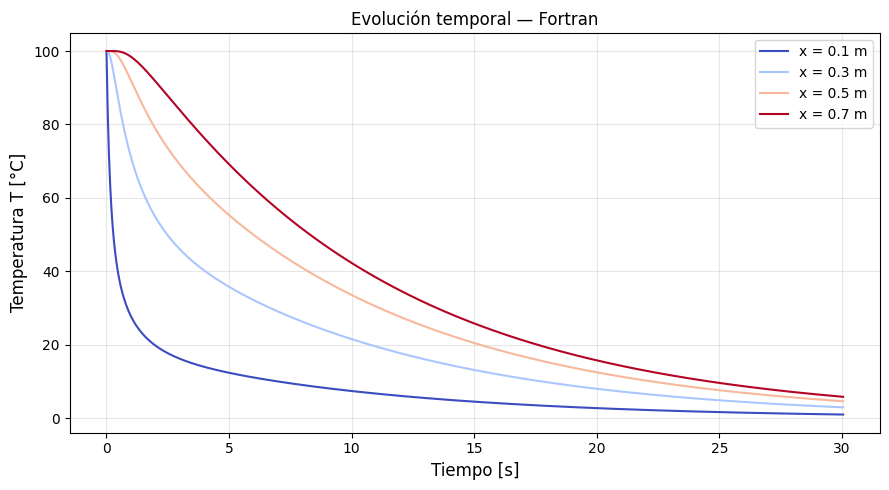

In [21]:
puntos_f = [1, 3, 5, 7]    # índices columnas de T_f
colores  = cm.coolwarm(np.linspace(0, 1, len(puntos_f)))

x_f = np.linspace(0, L, N + 1)   # 11 puntos: 0.0, 0.1, ..., 1.0

fig, ax = plt.subplots(figsize=(9, 5))

for idx_x, color in zip(puntos_f, colores):
    ax.plot(t_f, T_f[:, idx_x], color=color,
            label=f'x = {x_f[idx_x]:.1f} m')

ax.set_xlabel('Tiempo [s]', fontsize=12)
ax.set_ylabel('Temperatura T [°C]', fontsize=12)
ax.set_title('Evolución temporal — Fortran', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Gráfica 4F — Error absoluto Fortran vs Analítica

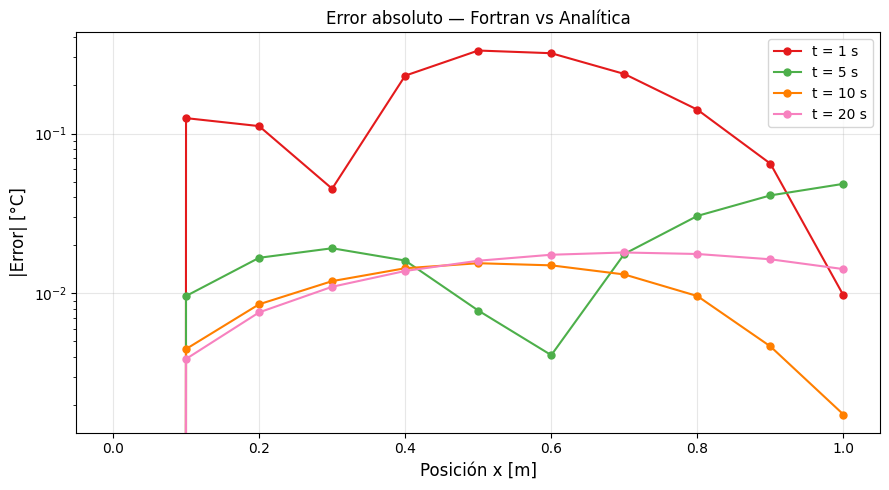

In [24]:
tiempos_error = [1, 5, 10, 20]
colores       = cm.Set1(np.linspace(0, 0.8, len(tiempos_error)))

x_f = np.linspace(0, L, N + 1)   # 11 puntos: 0.0, 0.1, ..., 1.0

fig, ax = plt.subplots(figsize=(9, 5))

for tp, color in zip(tiempos_error, colores):
    idx    = np.argmin(np.abs(t_f - tp))
    T_fila = np.concatenate([T_f[idx], [T_fd[idx]]])  # 10 puntos + frontera = 11
    err    = np.abs(T_fila - T_analitica(x_f, tp))

    ax.plot(x_f, err, '-o', color=color, markersize=5, label=f't = {tp} s')

ax.set_xlabel('Posición x [m]', fontsize=12)
ax.set_ylabel('|Error| [°C]', fontsize=12)
ax.set_title('Error absoluto — Fortran vs Analítica', fontsize=12)
ax.legend(fontsize=10)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Tabla — Fortran vs Analítica en $t = 5$ s

In [16]:
t_tabla = 5.0
idx     = np.argmin(np.abs(t_f - t_tabla))
T_fila  = np.concatenate([[0.0], T_f[idx]])
T_an    = T_analitica(x, t_tabla)

df_f = pd.DataFrame({
    'x [m]'       : np.round(x,                      2),
    'T Fortran'   : np.round(T_fila,                  4),
    'T analítico' : np.round(T_an,                    4),
    '|Error|'     : np.round(np.abs(T_fila - T_an),   6)
})

display(df_f)

,x [m],T Fortran,T analítico,|Error|
0,0.0,0.0000,0.0000,0.000000
1,0.1,0.0000,12.3869,12.386873
2,0.2,12.3965,24.4248,12.028306
3,0.3,24.4415,35.7830,11.341543
4,0.4,35.8022,46.1647,10.362452
5,0.5,46.1807,55.3176,9.136889
6,0.6,55.3254,63.0401,7.714707
7,0.7,63.0360,69.1806,6.144556
8,0.8,69.1629,73.6327,4.469819
9,0.9,73.6022,76.3286,2.726424
